# Donor Prediction Model — Supervised & Unsupervised Learning

**Part 1 — Data Loading & Preprocessing**  
**Part 2 — Exploratory Data Analysis (EDA)**  
**Part 3 — Supervised Learning** (Logistic Regression, Random Forest, Decision Tree, KNN, Naive Bayes, AdaBoost, Gradient Boosting)  
**Part 4 — Unsupervised Learning** (K-Means DBSCAN)  
**Part 5 — Model Comparison & Final Summary**

---
## Part 1 — Data Loading & Preprocessing

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [11]:
# UPDATE the paths below to match your local file locations.
donor_df = pd.read_csv('Donor_2020_08_02_temp.csv')
non_donor_df = pd.read_csv('NonDonor_2020_08_02_temp.csv')

print(f'Donor records      : {donor_df.shape}')
print(f'Non-Donor records  : {non_donor_df.shape}')
donor_df.head()

Donor records      : (45671, 14)
Non-Donor records  : (164607, 14)


,MillenniumID,ResidenceType,College,EventsAttended,AthleticsCount,AwardCount,FraternitySororityCount,StudentOrganizationCount,ScholarshipCount,Gender,MartialStatus,Birthday,NumberofDegrees,FirstGradYear
0,91,Home,Arts and Media,0,0,0,1,0,0,F,Single,1938-06-18,1,1959
1,745,Home,Science and Engineering,1,0,0,2,0,0,F,Married,1946-12-21,1,1969
2,1321,Home,Education and Human Services,0,0,0,0,0,0,M,Single,1944-07-25,3,1981
3,1933,Home,Business Administration,4,0,0,0,0,0,M,Single,1941-01-31,1,1969
4,2006,Home,Education and Human Services,0,0,0,1,0,0,M,Married,1942-11-05,1,1965


In [12]:
# Label Creation
donor_df['Donation'] = 1
non_donor_df['Donation'] = 0

print('Donor label distribution  :', donor_df['Donation'].value_counts().to_dict())
print('NonDonor label distribution:', non_donor_df['Donation'].value_counts().to_dict())

Donor label distribution  : {1: 45671}
NonDonor label distribution: {0: 164607}


In [13]:
# Handle Missing Values & Birthday -> Age
donor_df.dropna(subset=['Birthday'], inplace=True)
non_donor_df.dropna(subset=['Birthday'], inplace=True)

donor_df['Birthday'] = pd.to_datetime(donor_df['Birthday'], errors='coerce').dt.year
non_donor_df['Birthday'] = pd.to_datetime(non_donor_df['Birthday'], errors='coerce').dt.year

current_year = datetime.now().year
donor_df['Age'] = current_year - donor_df['Birthday']
non_donor_df['Age'] = current_year - non_donor_df['Birthday']

donor_df.drop(columns=['Birthday', 'MillenniumID'], inplace=True)
non_donor_df.drop(columns=['Birthday', 'MillenniumID'], inplace=True)

print(f'Donor shape after cleaning   : {donor_df.shape}')
print(f'NonDonor shape after cleaning : {non_donor_df.shape}')

Donor shape after cleaning   : (45544, 14)
NonDonor shape after cleaning : (164266, 14)


In [14]:
# Balance the Dataset (undersample non-donors)
donor_length = len(donor_df)
non_donor_sampled = non_donor_df.sample(n=donor_length, random_state=42)

print(f'Balanced: Donor = {len(donor_df)}, NonDonor = {len(non_donor_sampled)}')

Balanced: Donor = 45544, NonDonor = 45544


In [15]:
# Select Features & Merge
final_features = [
    'ResidenceType', 'College', 'EventsAttended', 'AthleticsCount',
    'AwardCount', 'FraternitySororityCount', 'StudentOrganizationCount',
    'ScholarshipCount', 'Gender', 'MartialStatus', 'NumberofDegrees',
    'FirstGradYear', 'Donation', 'Age'
]

donor_df = donor_df[final_features]
non_donor_sampled = non_donor_sampled[final_features]

cleaned_df = pd.concat([donor_df, non_donor_sampled], ignore_index=True)
print(f'Combined dataset shape: {cleaned_df.shape}')
print(f'\nClass distribution:\n{cleaned_df["Donation"].value_counts()}')

Combined dataset shape: (91088, 14)

Class distribution:
Donation
1    45544
0    45544
Name: count, dtype: int64


In [16]:
# Log Transform Skewed Features & MinMax Scaling
from sklearn.preprocessing import MinMaxScaler

cleaned_df['Age'] = np.log1p(cleaned_df['Age'])
cleaned_df['FirstGradYear'] = np.log1p(cleaned_df['FirstGradYear'])

numerical_features = [
    'Age', 'EventsAttended', 'AthleticsCount', 'AwardCount',
    'FraternitySororityCount', 'StudentOrganizationCount',
    'ScholarshipCount', 'NumberofDegrees', 'FirstGradYear'
]

scaler = MinMaxScaler()
cleaned_df[numerical_features] = scaler.fit_transform(cleaned_df[numerical_features])

print('Numerical features scaled (MinMax 0-1).')
cleaned_df[numerical_features].describe().round(3)

Numerical features scaled (MinMax 0-1).


,Age,EventsAttended,AthleticsCount,AwardCount,FraternitySororityCount,StudentOrganizationCount,ScholarshipCount,NumberofDegrees,FirstGradYear
count,91088.000,91088.000,91088.000,91088.000,91088.000,91088.000,91088.000,91088.000,91088.000
mean,0.545,0.002,0.007,0.028,0.029,0.013,0.019,0.044,0.729
std,0.195,0.010,0.040,0.074,0.086,0.041,0.100,0.096,0.157
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.414,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.601
50%,0.588,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.728
75%,0.700,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.865
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [17]:
# One-Hot Encode Categorical Features
categorical_features = ['ResidenceType', 'College', 'Gender', 'MartialStatus']
cleaned_df = pd.get_dummies(cleaned_df, columns=categorical_features, drop_first=True)

print(f'Final dataset shape: {cleaned_df.shape}')
print(f'Columns: {list(cleaned_df.columns)}')

Final dataset shape: (91088, 22)
Columns: ['EventsAttended', 'AthleticsCount', 'AwardCount', 'FraternitySororityCount', 'StudentOrganizationCount', 'ScholarshipCount', 'NumberofDegrees', 'FirstGradYear', 'Donation', 'Age', 'ResidenceType_Home', 'College_Business Administration', 'College_Education and Human Services', 'College_Global Campus', 'College_Graduate Studies', 'College_Health Professions', 'College_Honorary Degree', 'College_Liberal Arts and Social Sciences', 'College_Medicine', 'College_Science and Engineering', 'Gender_M', 'MartialStatus_Single']


In [18]:
# Train / Test Split
from sklearn.model_selection import train_test_split

X = cleaned_df.drop(columns=['Donation'])
y = cleaned_df['Donation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')
print(f'\nTrain class split:\n{y_train.value_counts()}')

X_train: (72870, 21)  |  X_test: (18218, 21)
y_train: (72870,)  |  y_test: (18218,)

Train class split:
Donation
1    36435
0    36435
Name: count, dtype: int64


---
## Part 2 — Exploratory Data Analysis (EDA)

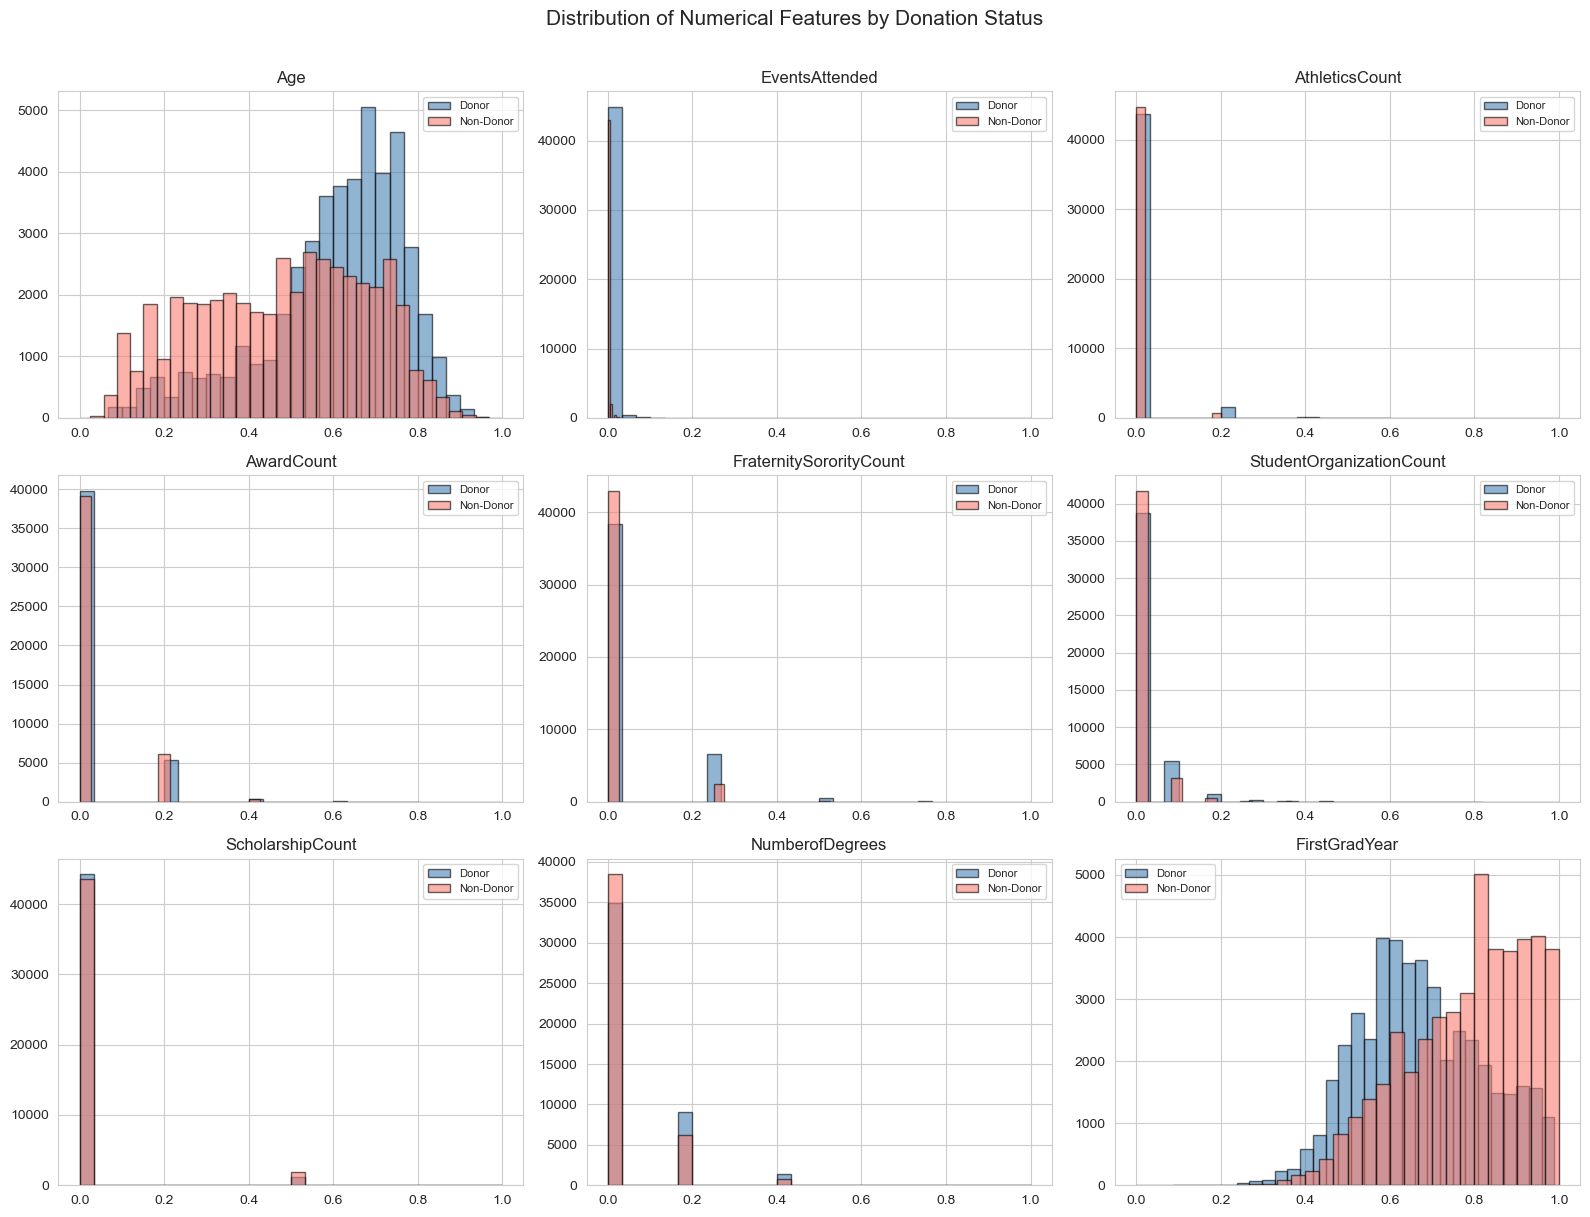

In [19]:
# Histograms of Numerical Features
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_features):
    axes[i].hist(cleaned_df[cleaned_df['Donation']==1][col], bins=30,
                 alpha=0.6, label='Donor', color='steelblue', edgecolor='black')
    axes[i].hist(cleaned_df[cleaned_df['Donation']==0][col], bins=30,
                 alpha=0.6, label='Non-Donor', color='salmon', edgecolor='black')
    axes[i].set_title(col, fontsize=12)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Numerical Features by Donation Status', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

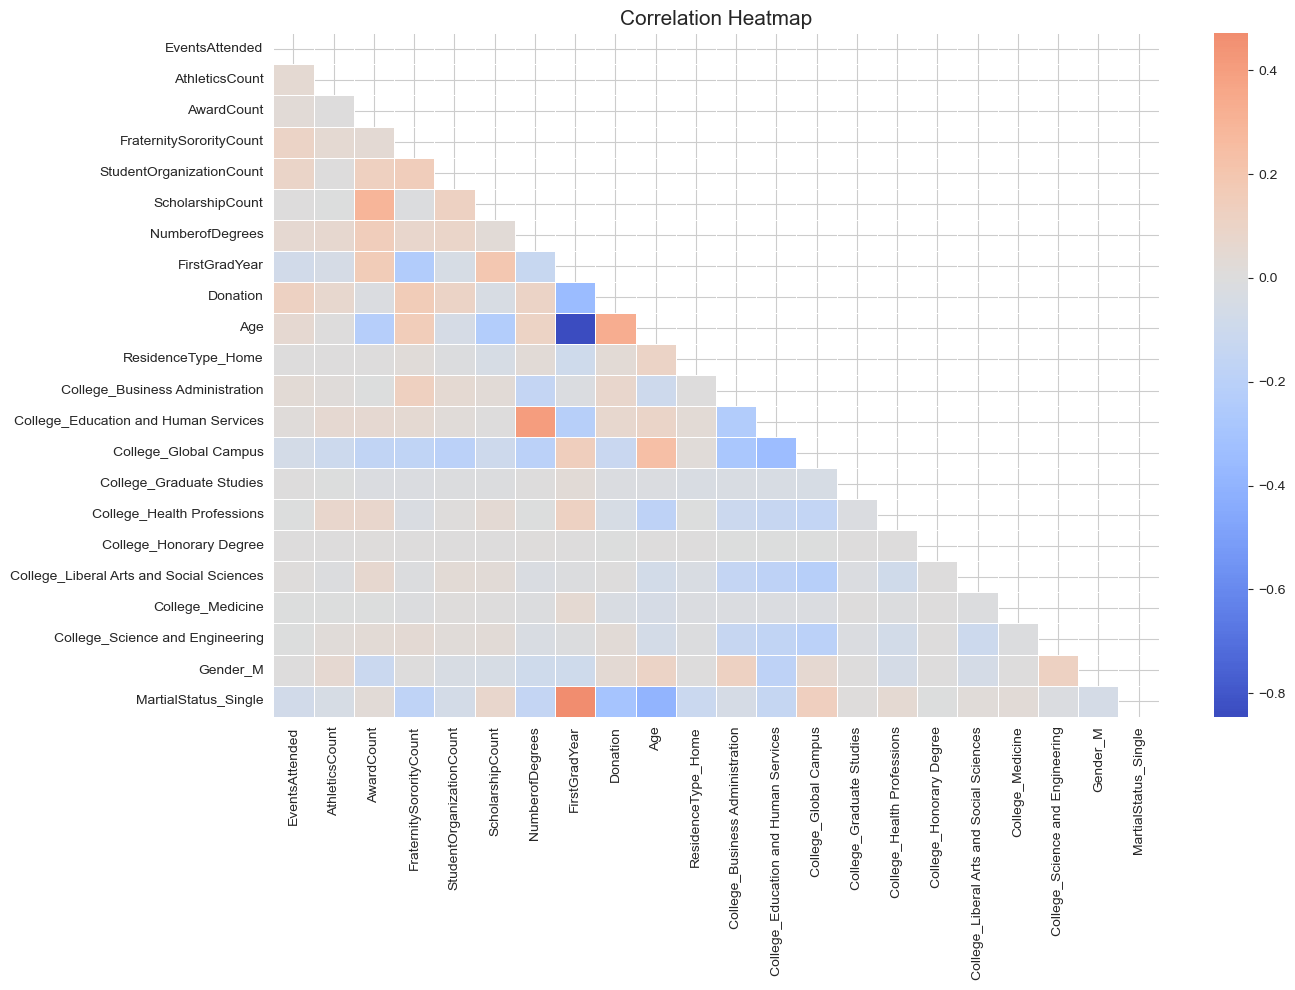

In [20]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
corr = cleaned_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()

Top Feature Correlations with Donation:

FirstGradYear                     -0.3561
Age                                0.3287
MartialStatus_Single              -0.3034
FraternitySororityCount            0.1596
College_Global Campus             -0.1244
EventsAttended                     0.1226
StudentOrganizationCount           0.1010
NumberofDegrees                    0.0987
College_Business Administration    0.0764
AthleticsCount                     0.0679
Name: Donation, dtype: float64


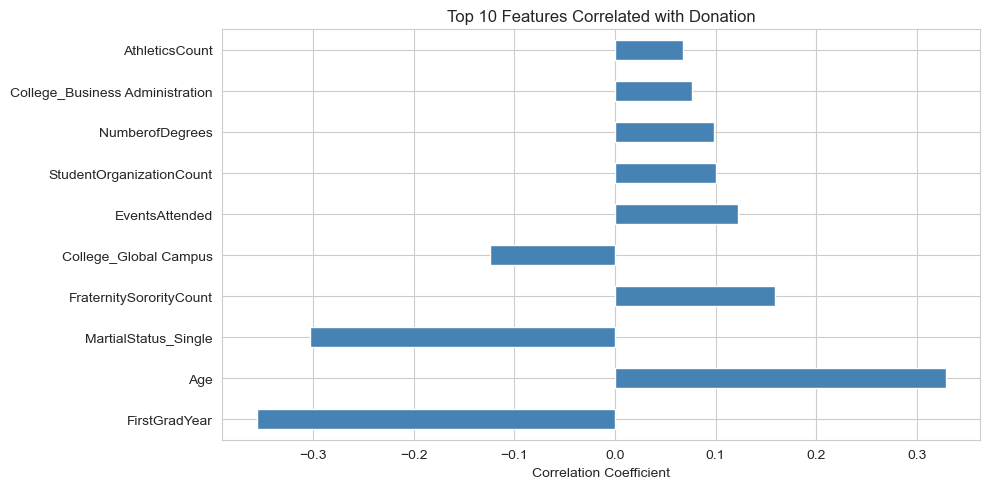

In [21]:
# Top Correlations with Donation
donation_corr = corr['Donation'].drop('Donation').sort_values(key=abs, ascending=False)
print('Top Feature Correlations with Donation:\n')
print(donation_corr.head(10).round(4))

fig, ax = plt.subplots(figsize=(10, 5))
donation_corr.head(10).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Features Correlated with Donation')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

---
## Part 3 — Supervised Learning

In [23]:
# Common Imports & Helper Function
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train, predict, and return a dict of metrics."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - t1

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
        roc_auc = roc_auc_score(y_te, y_prob)
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_te)
        roc_auc = roc_auc_score(y_te, y_prob)
    else:
        y_prob = None
        roc_auc = None

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'F0.5': fbeta_score(y_te, y_pred, beta=0.5),
        'ROC-AUC': roc_auc,
        'Train Time (s)': round(train_time, 3),
        'Predict Time (s)': round(pred_time, 3)
    }
    return metrics, y_pred, y_prob

all_results = []
all_predictions = {}
all_probabilities = {}

print('Helper function ready.')

Helper function ready.


### 3.1  Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
m, y_pred, y_prob = evaluate_model('Logistic Regression', lr, X_train, X_test, y_train, y_test)
all_results.append(m)
all_predictions['Logistic Regression'] = y_pred
all_probabilities['Logistic Regression'] = y_prob

print(f"Accuracy: {m['Accuracy']:.4f}  |  F1: {m['F1']:.4f}  |  ROC-AUC: {m['ROC-AUC']:.4f}")
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Non-Donor', 'Donor']))

Accuracy: 0.6991  |  F1: 0.7046  |  ROC-AUC: 0.7583

Classification Report:

              precision    recall  f1-score   support

   Non-Donor       0.71      0.68      0.69      9109
       Donor       0.69      0.72      0.70      9109

    accuracy                           0.70     18218
   macro avg       0.70      0.70      0.70     18218
weighted avg       0.70      0.70      0.70     18218



### 3.2  Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
m, y_pred, y_prob = evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test)
all_results.append(m)
all_predictions['Random Forest'] = y_pred
all_probabilities['Random Forest'] = y_prob

print(f"Accuracy: {m['Accuracy']:.4f}  |  F1: {m['F1']:.4f}  |  ROC-AUC: {m['ROC-AUC']:.4f}")
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Non-Donor', 'Donor']))

Accuracy: 0.6704  |  F1: 0.6744  |  ROC-AUC: 0.7207

Classification Report:

              precision    recall  f1-score   support

   Non-Donor       0.67      0.66      0.67      9109
       Donor       0.67      0.68      0.67      9109

    accuracy                           0.67     18218
   macro avg       0.67      0.67      0.67     18218
weighted avg       0.67      0.67      0.67     18218



### 3.3  K-Nearest Neighbors (KNN)

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7, n_jobs=1)
m, y_pred, y_prob = evaluate_model('KNN (k=7)', knn, X_train, X_test, y_train, y_test)
all_results.append(m)
all_predictions['KNN (k=7)'] = y_pred
all_probabilities['KNN (k=7)'] = y_prob

print(f"Accuracy: {m['Accuracy']:.4f}  |  F1: {m['F1']:.4f}  |  ROC-AUC: {m['ROC-AUC']:.4f}")
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Non-Donor', 'Donor']))

Accuracy: 0.6744  |  F1: 0.6721  |  ROC-AUC: 0.7231

Classification Report:

              precision    recall  f1-score   support

   Non-Donor       0.67      0.68      0.68      9109
       Donor       0.68      0.67      0.67      9109

    accuracy                           0.67     18218
   macro avg       0.67      0.67      0.67     18218
weighted avg       0.67      0.67      0.67     18218



### 3.4  Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, max_depth=10)
m, y_pred, y_prob = evaluate_model('Decision Tree', dt, X_train, X_test, y_train, y_test)
all_results.append(m)
all_predictions['Decision Tree'] = y_pred
all_probabilities['Decision Tree'] = y_prob

print(f"Accuracy: {m['Accuracy']:.4f}  |  F1: {m['F1']:.4f}  |  ROC-AUC: {m['ROC-AUC']:.4f}")
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Non-Donor', 'Donor']))

Accuracy: 0.7009  |  F1: 0.7024  |  ROC-AUC: 0.7570

Classification Report:

              precision    recall  f1-score   support

   Non-Donor       0.70      0.70      0.70      9109
       Donor       0.70      0.71      0.70      9109

    accuracy                           0.70     18218
   macro avg       0.70      0.70      0.70     18218
weighted avg       0.70      0.70      0.70     18218



### 3.5  Gaussian Naive Bayes

In [28]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
m, y_pred, y_prob = evaluate_model('Gaussian NB', gnb, X_train, X_test, y_train, y_test)
all_results.append(m)
all_predictions['Gaussian NB'] = y_pred
all_probabilities['Gaussian NB'] = y_prob

print(f"Accuracy: {m['Accuracy']:.4f}  |  F1: {m['F1']:.4f}  |  ROC-AUC: {m['ROC-AUC']:.4f}")
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Non-Donor', 'Donor']))

Accuracy: 0.5015  |  F1: 0.6661  |  ROC-AUC: 0.7286

Classification Report:

              precision    recall  f1-score   support

   Non-Donor       0.60      0.01      0.02      9109
       Donor       0.50      0.99      0.67      9109

    accuracy                           0.50     18218
   macro avg       0.55      0.50      0.34     18218
weighted avg       0.55      0.50      0.34     18218



### 3.6  AdaBoost

In [29]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
m, y_pred, y_prob = evaluate_model('AdaBoost', ada, X_train, X_test, y_train, y_test)
all_results.append(m)
all_predictions['AdaBoost'] = y_pred
all_probabilities['AdaBoost'] = y_prob

print(f"Accuracy: {m['Accuracy']:.4f}  |  F1: {m['F1']:.4f}  |  ROC-AUC: {m['ROC-AUC']:.4f}")
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Non-Donor', 'Donor']))

Accuracy: 0.6926  |  F1: 0.6977  |  ROC-AUC: 0.7517

Classification Report:

              precision    recall  f1-score   support

   Non-Donor       0.70      0.68      0.69      9109
       Donor       0.69      0.71      0.70      9109

    accuracy                           0.69     18218
   macro avg       0.69      0.69      0.69     18218
weighted avg       0.69      0.69      0.69     18218



### 3.7  Gradient Boosting

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
m, y_pred, y_prob = evaluate_model('Gradient Boosting', gb, X_train, X_test, y_train, y_test)
all_results.append(m)
all_predictions['Gradient Boosting'] = y_pred
all_probabilities['Gradient Boosting'] = y_prob

print(f"Accuracy: {m['Accuracy']:.4f}  |  F1: {m['F1']:.4f}  |  ROC-AUC: {m['ROC-AUC']:.4f}")
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Non-Donor', 'Donor']))

Accuracy: 0.7102  |  F1: 0.7143  |  ROC-AUC: 0.7711

Classification Report:

              precision    recall  f1-score   support

   Non-Donor       0.72      0.70      0.71      9109
       Donor       0.70      0.72      0.71      9109

    accuracy                           0.71     18218
   macro avg       0.71      0.71      0.71     18218
weighted avg       0.71      0.71      0.71     18218



### 3.8  Supervised Results Summary Table

In [31]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
results_df.style.highlight_max(
    subset=['Accuracy', 'Precision', 'Recall', 'F1', 'F0.5', 'ROC-AUC'],
    color='lightgreen'
)

,Model,Accuracy,Precision,Recall,F1,F0.5,ROC-AUC,Train Time (s),Predict Time (s)
0,Gradient Boosting,0.710177,0.704344,0.724448,0.714255,0.708275,0.771143,2.470000,0.013000
1,Logistic Regression,0.699144,0.692080,0.717532,0.704576,0.697025,0.758260,0.270000,0.002000
2,Decision Tree,0.700900,0.698870,0.706005,0.702419,0.700285,0.757020,0.102000,0.001000
3,AdaBoost,0.692612,0.686312,0.709518,0.697722,0.690831,0.751684,1.102000,0.030000
4,Random Forest,0.670381,0.666274,0.682731,0.674402,0.669502,0.720657,2.625000,0.245000
5,KNN (k=7),0.674388,0.676873,0.667362,0.672084,0.674949,0.723052,0.004000,0.480000
6,Gaussian NB,0.501482,0.500746,0.994291,0.666054,0.555937,0.728630,0.029000,0.003000


### 3.9  ROC Curves — All Models

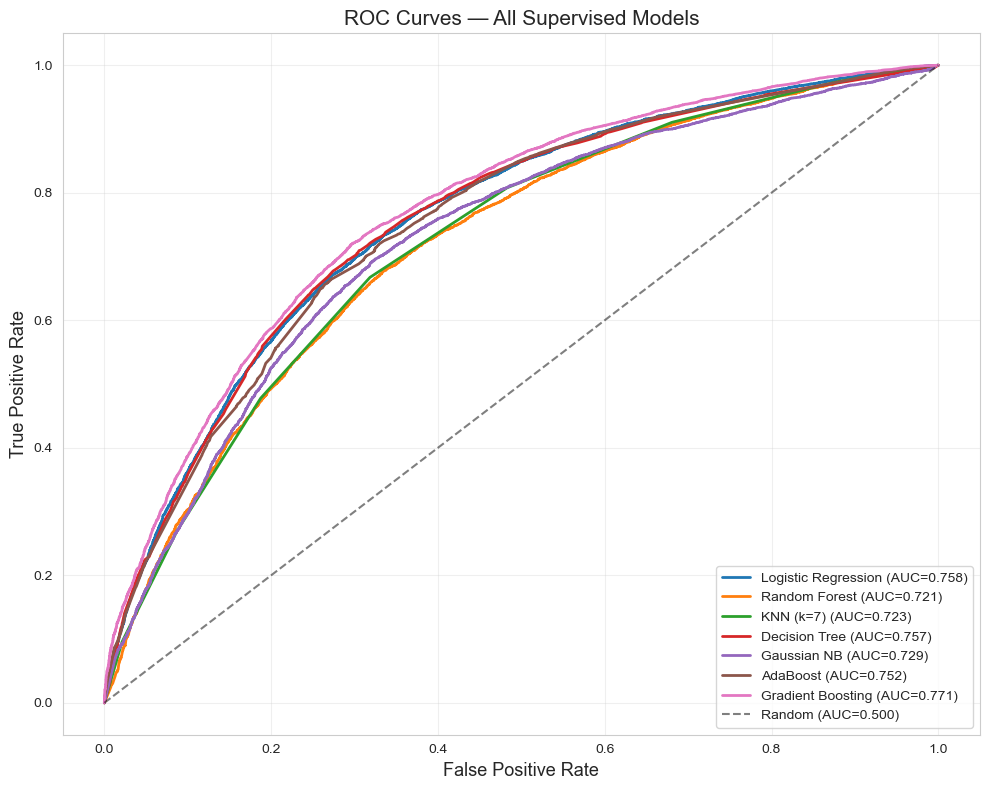

In [32]:
plt.figure(figsize=(10, 8))

for name, y_prob in all_probabilities.items():
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves — All Supervised Models', fontsize=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.10  Confusion Matrices

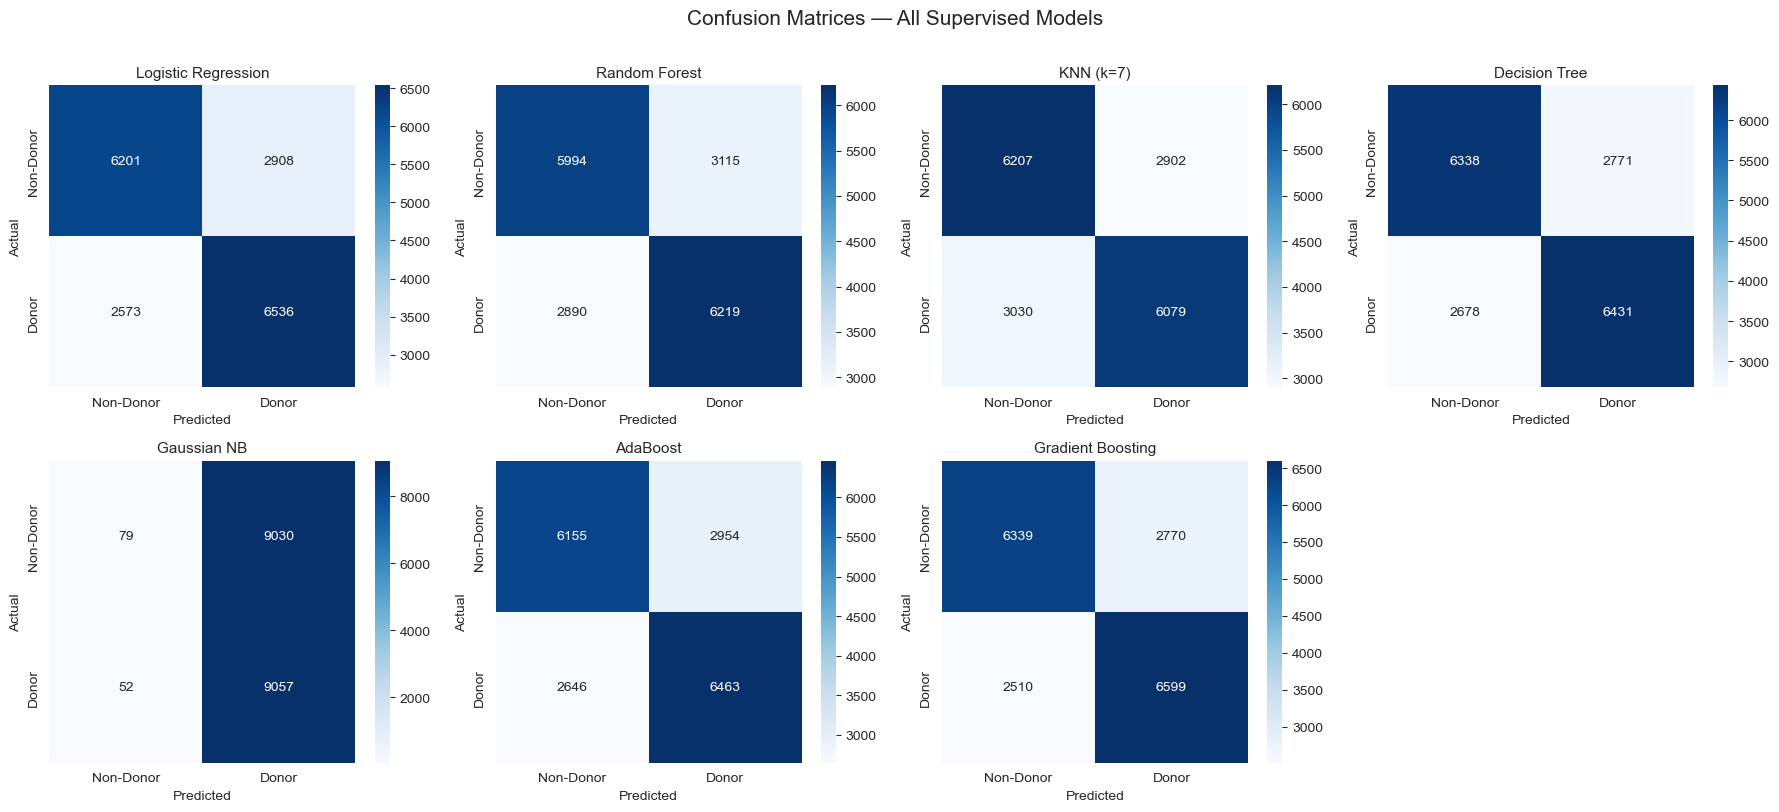

In [33]:
n_models = len(all_predictions)
cols = 4
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.ravel()

for i, (name, y_pred) in enumerate(all_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Non-Donor', 'Donor'],
                yticklabels=['Non-Donor', 'Donor'])
    axes[i].set_title(name, fontsize=11)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Supervised Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 3.11  Feature Importance (Random Forest + AdaBoost)

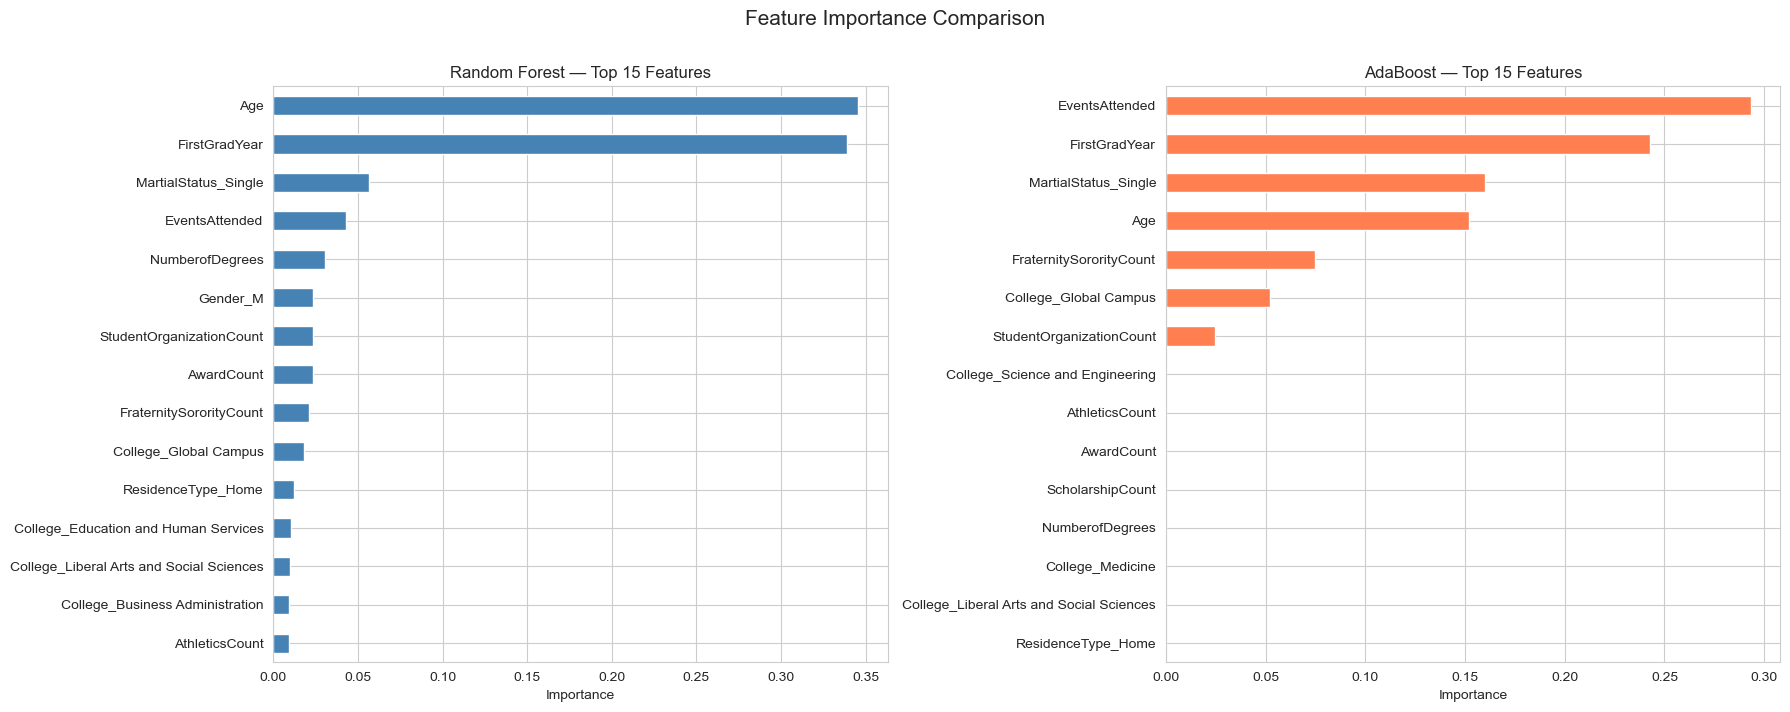

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

rf_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
rf_imp.tail(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest — Top 15 Features')
axes[0].set_xlabel('Importance')

ada_imp = pd.Series(ada.feature_importances_, index=X_train.columns).sort_values(ascending=True)
ada_imp.tail(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('AdaBoost — Top 15 Features')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## Part 4 — Unsupervised Learning

In [35]:
# Prepare data for clustering
from sklearn.preprocessing import StandardScaler

X_unsup = cleaned_df.drop(columns=['Donation']).copy()
y_true_labels = cleaned_df['Donation'].values

scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(X_unsup)

print(f'Unsupervised data shape: {X_scaled.shape}')

Unsupervised data shape: (91088, 21)


### 4.1  PCA — Dimensionality Reduction & Visualization

Components needed for 90% variance: 16


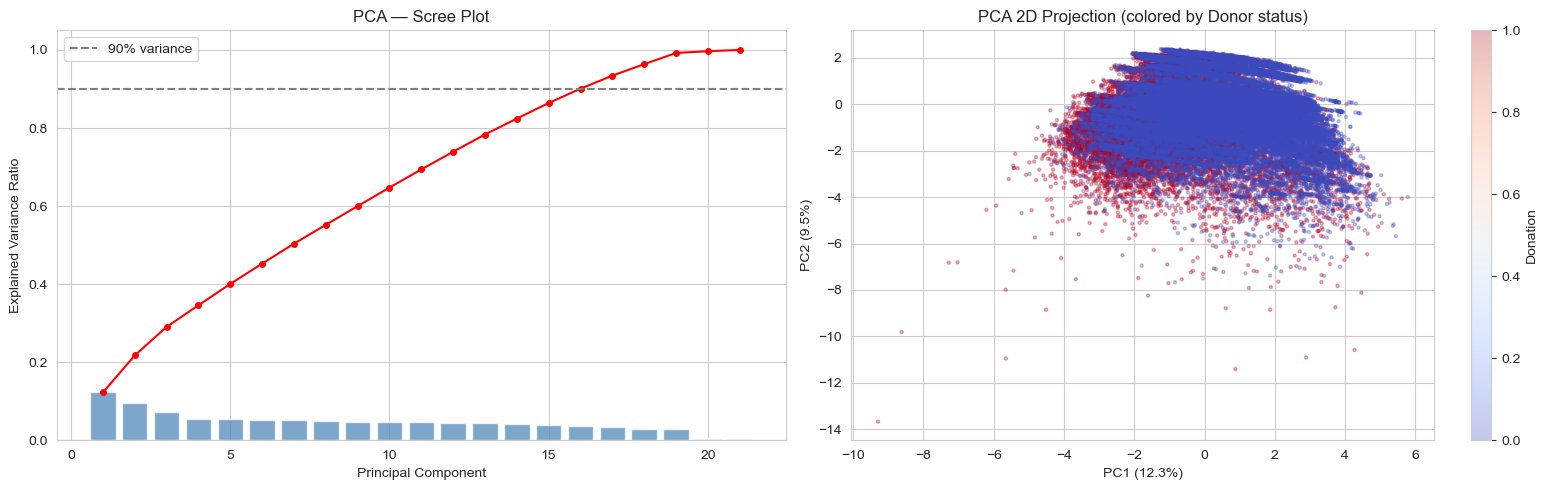

In [36]:
from sklearn.decomposition import PCA

# Full PCA for variance analysis
pca_full = PCA().fit(X_scaled)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[0].plot(range(1, len(cumulative_var) + 1), cumulative_var, 'ro-', markersize=4)
axes[0].axhline(y=0.90, color='gray', linestyle='--', label='90% variance')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA — Scree Plot')
axes[0].legend()

n_comp_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f'Components needed for 90% variance: {n_comp_90}')

# 2D projection colored by actual label
pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_scaled)

scatter = axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_true_labels,
                          cmap='coolwarm', alpha=0.3, s=5)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA 2D Projection (colored by Donor status)')
plt.colorbar(scatter, ax=axes[1], label='Donation')

plt.tight_layout()
plt.show()

In [37]:
# PCA-reduced data for clustering
pca_cluster = PCA(n_components=n_comp_90)
X_pca = pca_cluster.fit_transform(X_scaled)
print(f'PCA-reduced shape for clustering: {X_pca.shape}')

PCA-reduced shape for clustering: (91088, 16)


### 4.2  K-Means Clustering

  k=2  |  Inertia=1558390  |  Silhouette=0.1269
  k=3  |  Inertia=1434596  |  Silhouette=0.1309
  k=4  |  Inertia=1343481  |  Silhouette=0.1369
  k=5  |  Inertia=1257996  |  Silhouette=0.1694
  k=6  |  Inertia=1163161  |  Silhouette=0.1771
  k=7  |  Inertia=1071816  |  Silhouette=0.2716
  k=8  |  Inertia=979929  |  Silhouette=0.2717


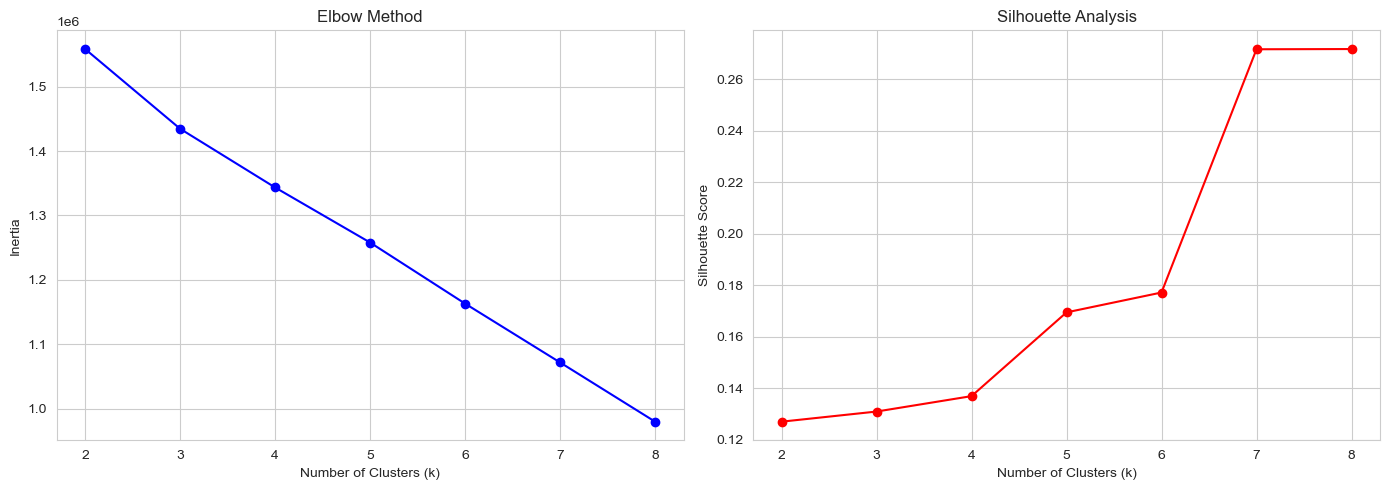

In [38]:
# Elbow Method & Silhouette Analysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=200)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, km.labels_, sample_size=5000, random_state=42))
    print(f'  k={k}  |  Inertia={km.inertia_:.0f}  |  Silhouette={silhouettes[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

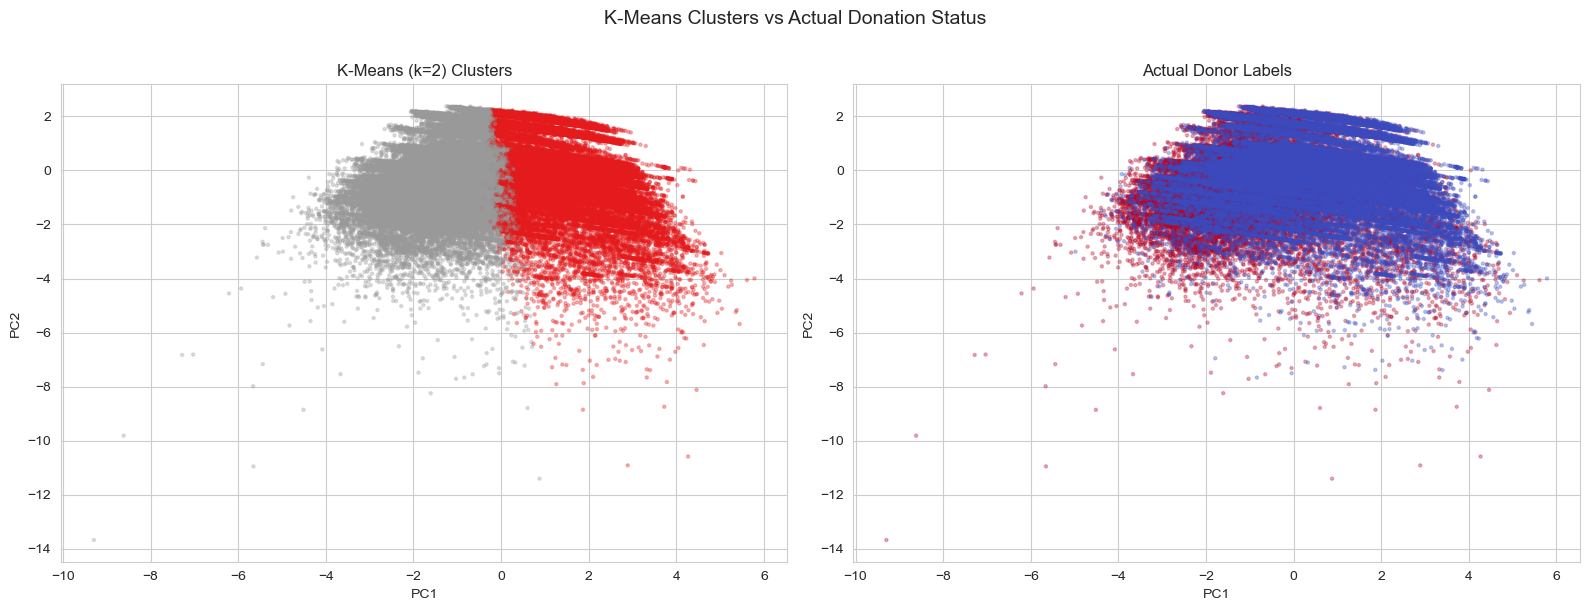

Cluster vs Actual Label Cross-Tab:

Cluster      0      1
Actual               
0        30342  15202
1        13736  31808


In [39]:
# K-Means with k=2 (natural donor / non-donor split)
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
km2_labels = km2.fit_predict(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=km2_labels, cmap='Set1', alpha=0.3, s=5)
axes[0].set_title('K-Means (k=2) Clusters')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_true_labels, cmap='coolwarm', alpha=0.3, s=5)
axes[1].set_title('Actual Donor Labels')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.suptitle('K-Means Clusters vs Actual Donation Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

ct = pd.crosstab(y_true_labels, km2_labels, rownames=['Actual'], colnames=['Cluster'])
print('Cluster vs Actual Label Cross-Tab:\n')
print(ct)

In [40]:
# K-Means Cluster Profiles
cluster_profile = cleaned_df.copy()
cluster_profile['Cluster'] = km2_labels

print('Mean feature values per K-Means cluster:\n')
profile_means = cluster_profile.groupby('Cluster').mean()
print(profile_means[numerical_features + ['Donation']].round(3).T)

Mean feature values per K-Means cluster:

Cluster                       0      1
Age                       0.410  0.670
EventsAttended            0.001  0.003
AthleticsCount            0.004  0.009
AwardCount                0.038  0.019
FraternitySororityCount   0.005  0.051
StudentOrganizationCount  0.010  0.016
ScholarshipCount          0.037  0.001
NumberofDegrees           0.023  0.065
FirstGradYear             0.855  0.612
Donation                  0.312  0.677


### 4.4  DBSCAN Clustering

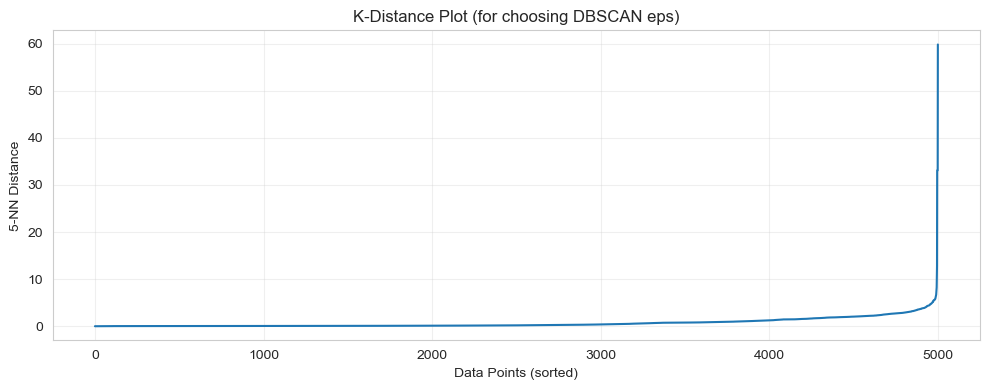

Chosen eps (95th percentile): 2.72


In [42]:
from sklearn.cluster import DBSCAN

# Use a sample for eps estimation
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
eps_sample_idx = np.random.choice(len(X_pca), size=5000, replace=False)
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca[eps_sample_idx])
distances, _ = nn.kneighbors(X_pca[eps_sample_idx])
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_dist)
plt.xlabel('Data Points (sorted)')
plt.ylabel('5-NN Distance')
plt.title('K-Distance Plot (for choosing DBSCAN eps)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

eps_val = np.percentile(k_dist, 95)
print(f'Chosen eps (95th percentile): {eps_val:.2f}')

DBSCAN found 24 clusters and 736 noise points (0.8% noise)


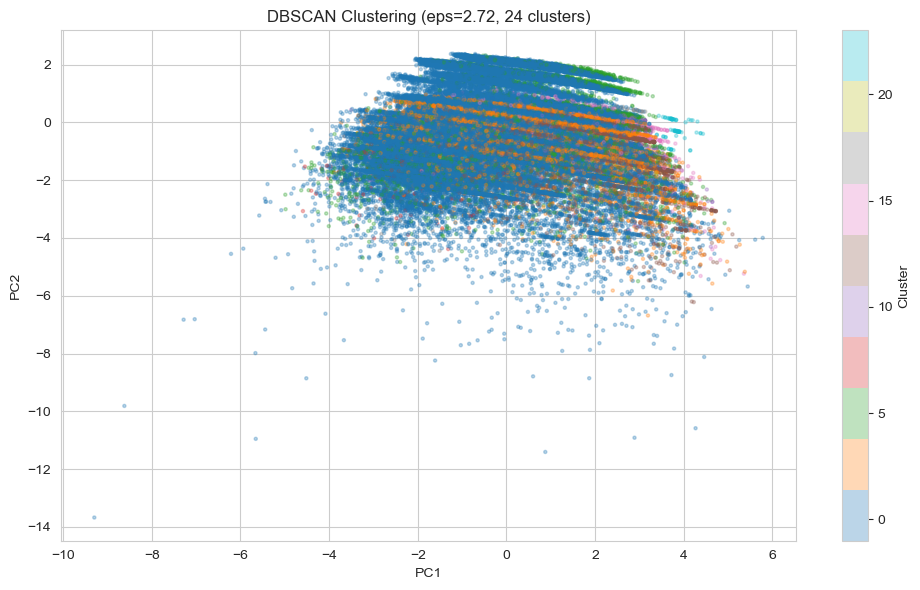

DBSCAN Silhouette Score (excl. noise): 0.2570


In [43]:
# DBSCAN Fit & Visualize
dbscan = DBSCAN(eps=eps_val, min_samples=10)
db_labels = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(db_labels) - {-1})
n_noise = (db_labels == -1).sum()

print(f'DBSCAN found {n_clusters_db} clusters and {n_noise} noise points '
      f'({n_noise / len(db_labels) * 100:.1f}% noise)')

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=db_labels, cmap='tab10',
                      alpha=0.3, s=5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN Clustering (eps={eps_val:.2f}, {n_clusters_db} clusters)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

if n_clusters_db >= 2:
    mask = db_labels != -1
    sil_db = silhouette_score(X_pca[mask], db_labels[mask],
                              sample_size=min(5000, mask.sum()), random_state=42)
    print(f'DBSCAN Silhouette Score (excl. noise): {sil_db:.4f}')

### 4.5  Unsupervised Results Summary

In [45]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

unsup_results = []

# K-Means
sil_km = silhouette_score(X_pca, km2_labels, sample_size=5000, random_state=42)
ari_km = adjusted_rand_score(y_true_labels, km2_labels)
nmi_km = normalized_mutual_info_score(y_true_labels, km2_labels)
unsup_results.append({'Method': 'K-Means (k=2)', 'Silhouette': round(sil_km, 4),
                       'Adjusted Rand Index': round(ari_km, 4), 'NMI': round(nmi_km, 4)})


# DBSCAN
if n_clusters_db >= 2:
    mask_db = db_labels != -1
    ari_db = adjusted_rand_score(y_true_labels[mask_db], db_labels[mask_db])
    nmi_db = normalized_mutual_info_score(y_true_labels[mask_db], db_labels[mask_db])
    unsup_results.append({'Method': f'DBSCAN ({n_clusters_db} clusters)',
                          'Silhouette': round(sil_db, 4),
                          'Adjusted Rand Index': round(ari_db, 4), 'NMI': round(nmi_db, 4)})

unsup_df = pd.DataFrame(unsup_results)
print('Unsupervised Clustering Comparison:\n')
print(unsup_df.to_string(index=False))

Unsupervised Clustering Comparison:

              Method  Silhouette  Adjusted Rand Index    NMI
       K-Means (k=2)      0.1269               0.1329 0.0983
DBSCAN (24 clusters)      0.2570               0.0005 0.0056


---
## Part 5 — Final Summary & Comparison

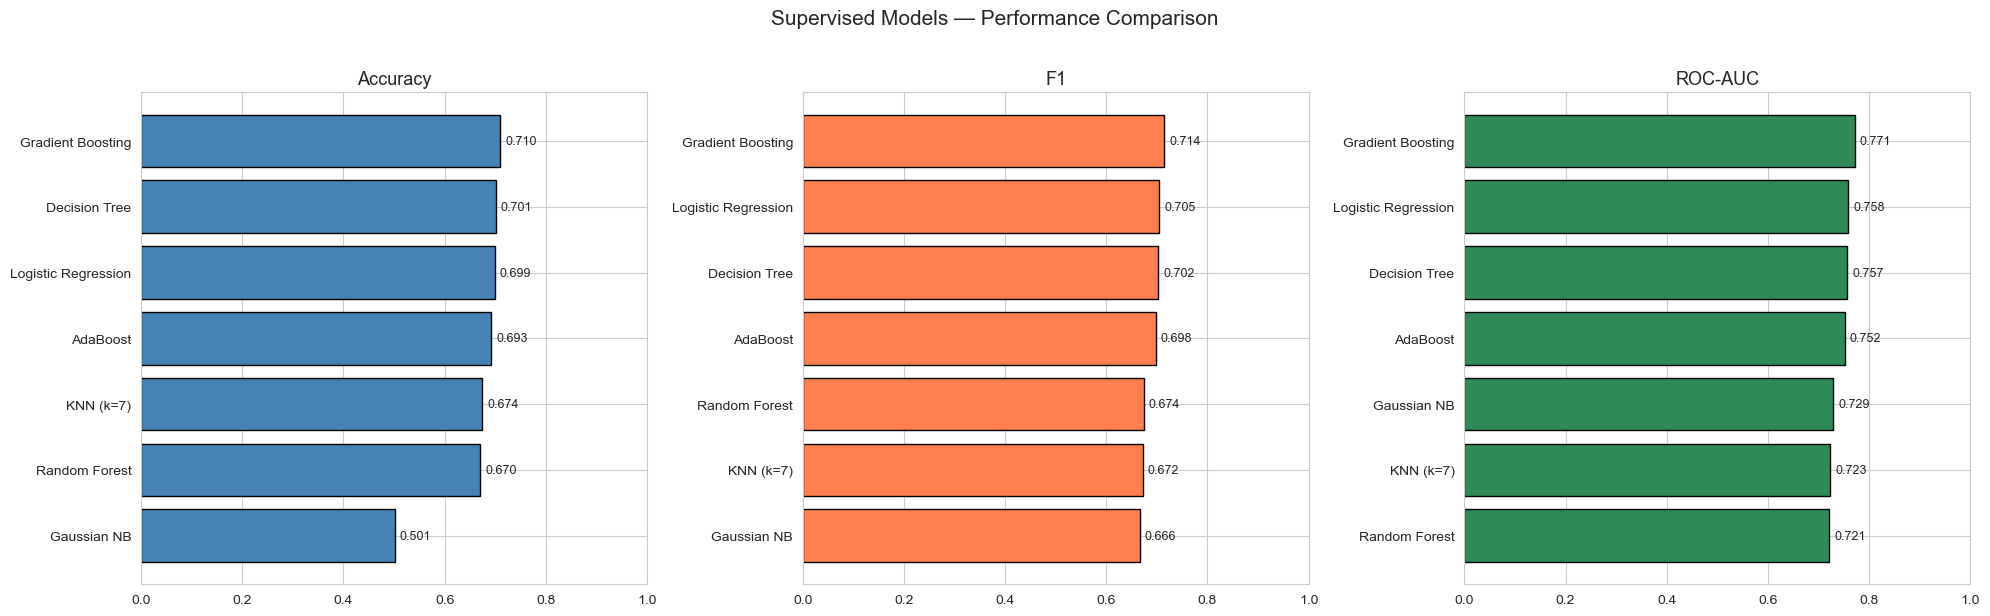

In [46]:
# Supervised Model Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC']
colors = ['steelblue', 'coral', 'seagreen']

for i, metric in enumerate(metrics_to_plot):
    sorted_df = results_df.sort_values(metric, ascending=True)
    axes[i].barh(sorted_df['Model'], sorted_df[metric], color=colors[i], edgecolor='black')
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_xlim(0, 1)
    for j, v in enumerate(sorted_df[metric].values):
        if v is not None:
            axes[i].text(v + 0.01, j, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Supervised Models — Performance Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [47]:
# Final Results Table
print('='*80)
print('SUPERVISED LEARNING RESULTS')
print('='*80)
print(results_df.to_string(index=False))

print('\n')
print('='*80)
print('UNSUPERVISED LEARNING RESULTS')
print('='*80)
print(unsup_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1']
print(f'\n>>> Best Supervised Model: {best_model_name} (F1 = {best_f1:.4f})')

SUPERVISED LEARNING RESULTS
              Model  Accuracy  Precision   Recall       F1     F0.5  ROC-AUC  Train Time (s)  Predict Time (s)
  Gradient Boosting  0.710177   0.704344 0.724448 0.714255 0.708275 0.771143           2.470             0.013
Logistic Regression  0.699144   0.692080 0.717532 0.704576 0.697025 0.758260           0.270             0.002
      Decision Tree  0.700900   0.698870 0.706005 0.702419 0.700285 0.757020           0.102             0.001
           AdaBoost  0.692612   0.686312 0.709518 0.697722 0.690831 0.751684           1.102             0.030
      Random Forest  0.670381   0.666274 0.682731 0.674402 0.669502 0.720657           2.625             0.245
          KNN (k=7)  0.674388   0.676873 0.667362 0.672084 0.674949 0.723052           0.004             0.480
        Gaussian NB  0.501482   0.500746 0.994291 0.666054 0.555937 0.728630           0.029             0.003


UNSUPERVISED LEARNING RESULTS
              Method  Silhouette  Adjusted Rand Inde